# 03 -- Centrosomes drive chromosome motion

Three independent lines of evidence that centrosome positions can be
treated as autonomous inputs when modeling chromosome dynamics:

**Part A (model-free):** The center of mass of the chromosome cloud
tracks the center of mass of the two poles with a visible time lag —
chromosomes follow centrosomes, not the other way around.

**Part B (model-based):** Fitting and simulating centrosome dynamics
shows that adding chromosome-on-centrosome forces provides no
improvement over a simple distance-dependent separation term.
Validated by F-test, cross-validation, and forward simulation.

**Part C (physics):** Back-of-the-envelope estimate shows chromosome
forces are an order of magnitude too weak to steer the spindle.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from scipy.linalg import block_diag

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.analysis.lag_correlation import compute_lag_correlation, plot_lag_correlation
from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import trim_trajectory

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
CONDITION = "rpe18_ctr"          # Analyze the control condition used throughout the SFI notebooks.
FRAC_NEB_AO_WINDOW = 0.4         # Trim each cell to this fraction of the NEB-to-AO window.
EXAMPLE_CELL = 1                 # Cell index used for the illustrative PCA trajectory panel.

In [3]:
cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac", frac=FRAC_NEB_AO_WINDOW) for c in cells_raw]
print(f"Loaded {len(cells)} {CONDITION} cells (trimmed to neb_ao_frac={FRAC_NEB_AO_WINDOW:.3f})")

Loaded 12 rpe18_ctr cells (trimmed to neb_ao_frac=0.400)


## Part A — Model-free evidence

### Example: trajectories in PCA space

We project all trajectories — individual chromosomes, both poles, pole
center of mass, chromosome center of mass — into PCA coordinates computed
from the chromosome center of mass.  Color encodes time (light → dark).

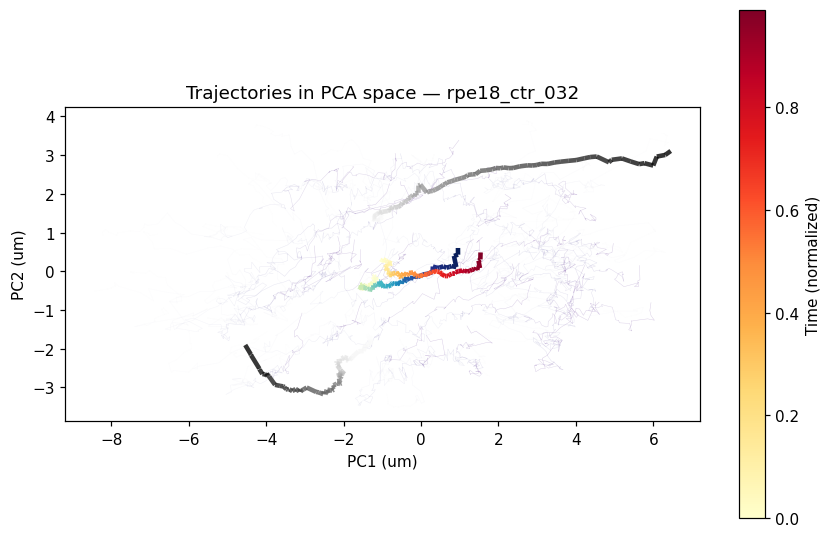

In [4]:
def _colorline(ax, x, y, t, cmap, linewidth=1.5, alpha=1.0):
    """Plot a line colored by a scalar parameter *t*."""
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, linewidths=linewidth, alpha=alpha)
    lc.set_array(t[:-1])
    ax.add_collection(lc)
    return lc


cell = cells[EXAMPLE_CELL]
T = cell.chromosomes.shape[0]
n_chrom = cell.chromosomes.shape[2]
t_color = np.linspace(0, 1, T)  # normalized time for colormaps

# Centers of mass
pole_com = 0.5 * (cell.centrioles[:, :, 0] + cell.centrioles[:, :, 1])
chrom_com = np.nanmean(cell.chromosomes, axis=2)

# PCA on chromosome center of mass, centered on its time-average
origin = chrom_com.mean(axis=0)
chrom_com_centered = chrom_com - origin
_, _, Vt = np.linalg.svd(chrom_com_centered, full_matrices=False)
pca_basis = Vt[:2].T  # (3, 2)

# Project everything into PCA space
chrom_com_pca = chrom_com_centered @ pca_basis
pole_com_pca = (pole_com - origin) @ pca_basis
p1_pca = (cell.centrioles[:, :, 0] - origin) @ pca_basis
p2_pca = (cell.centrioles[:, :, 1] - origin) @ pca_basis

fig, ax = plt.subplots(figsize=(8, 5))

# Individual chromosome trajectories (thin, purple, semi-transparent)
for j in range(n_chrom):
    chrom_j = cell.chromosomes[:, :, j]
    if np.any(np.isnan(chrom_j)):
        continue
    cj_pca = (chrom_j - origin) @ pca_basis
    _colorline(ax, cj_pca[:, 0], cj_pca[:, 1], t_color, "Purples",
               linewidth=0.3, alpha=0.2)

# Both individual poles (gray, thick)
_colorline(ax, p1_pca[:, 0], p1_pca[:, 1], t_color, "Greys", linewidth=3, alpha=0.8)
_colorline(ax, p2_pca[:, 0], p2_pca[:, 1], t_color, "Greys", linewidth=3, alpha=0.8)

# Pole center of mass (blue, thick)
_colorline(ax, pole_com_pca[:, 0], pole_com_pca[:, 1], t_color, "YlGnBu", linewidth=3)

# Chromosome center of mass (red, thick)
lc = _colorline(ax, chrom_com_pca[:, 0], chrom_com_pca[:, 1], t_color, "YlOrRd", linewidth=3)

ax.autoscale()
ax.set_aspect("equal")
ax.set_xlabel("PC1 (um)")
ax.set_ylabel("PC2 (um)")
ax.set_title(f"Trajectories in PCA space — {cell.cell_id}")
fig.colorbar(lc, ax=ax, label="Time (normalized)")
fig.tight_layout()
plt.show()

### Lag correlation across all cells

Normalized dot-product cross-correlation between pole-center velocity and
chromosome-center velocity over the prometaphase window, as a function of
time lag. A peak at positive lag (and slower decay on the positive side)
means chromosomes follow poles.

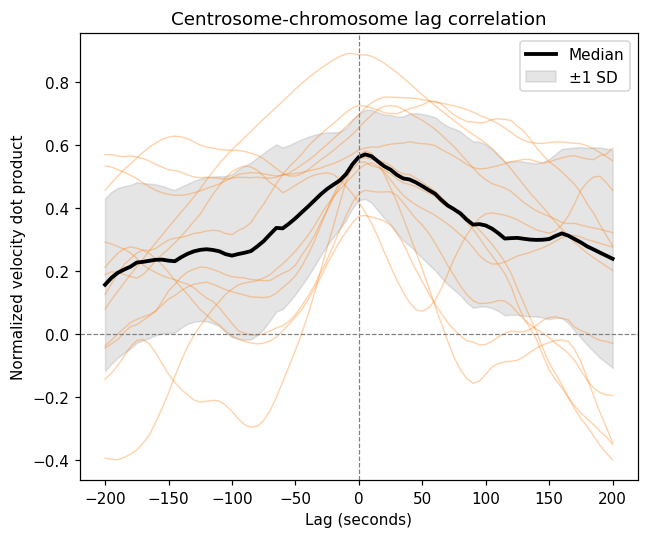

Peak correlation lag: 5 s
Peak correlation value: 0.570


In [5]:
lag_result = compute_lag_correlation(cells, lag_max=40, smooth_window=25)
plot_lag_correlation(lag_result)
plt.show()

peak_idx = int(np.nanargmax(lag_result.median))
print(f"Peak correlation lag: {lag_result.lags[peak_idx]:.0f} s")
print(f"Peak correlation value: {lag_result.median[peak_idx]:.3f}")

## Part B — Chromosome feedback on centrosomes is negligible

We now ask: does adding chromosome-on-centrosome forces improve our
ability to predict centrosome velocities?  If pole velocities are already
well-predicted by a distance-dependent pole-separation term alone, then
chromosome feedback is not a missing ingredient and we can treat
centrosome positions as given/external when modeling chromosome dynamics.

Note: the pole-separation term $f_{pp}$ is an *effective* force that
absorbs all contributions driving pole separation (including cortical
pulling forces, motor-driven sliding, etc.) -- it is not a literal
pole-pole interaction.

We fit centrosome velocity using two potential force sources:
- $f_{pp}(r)$: effective pole-separation force (distance-dependent)
- $f_{cp}(r)$: chromosome-on-pole (all 46 chromosomes acting on each pole)

and compare how much each contributes.

In [6]:
from chromlearn.model_fitting.basis import BSplineBasis

# Match the main fitter's light ridge + stronger roughness prior so the
# kernel shape reflects smooth spindle dynamics rather than basis jitter.
LAMBDA_RIDGE = 1e-3
LAMBDA_ROUGH = 1.0


# Fixed a priori basis domains (same as nb04) to avoid leaking held-out
# cell information into the basis during cross-validation.
R_MIN = 0.3   # um -- tracking resolution floor
R_MAX = 15.0  # um -- conservative spindle-scale upper bound

# Collect empirical distances for plotting and sanity checks only.
all_pp_dists = []
all_cp_dists = []
for cell in cells:
    pp = np.linalg.norm(cell.centrioles[:, :, 1] - cell.centrioles[:, :, 0], axis=1)
    all_pp_dists.extend(pp)

    poles = np.moveaxis(cell.centrioles, 2, 1)      # (T, 2, 3)
    chroms = np.moveaxis(cell.chromosomes, 2, 1)    # (T, N, 3)
    for t in range(chroms.shape[0]):
        chroms_t = chroms[t]
        valid = ~np.any(np.isnan(chroms_t), axis=1)
        if not valid.any():
            continue
        chroms_valid = chroms_t[valid]
        for p in range(2):
            delta = chroms_valid - poles[t, p]
            dist = np.linalg.norm(delta, axis=1)
            all_cp_dists.extend(dist[dist > 1e-12])

all_pp_dists = np.array(all_pp_dists)
all_cp_dists = np.array(all_cp_dists)

# Build a small regression for centrosome velocity.
# Each centrosome's velocity at each timepoint is one observation (3 rows for x,y,z).
# Features: f_pp(pole-pole distance) * direction + sum_j f_cp(r_jp) * direction_jp

n_basis_pp = 6
n_basis_cp = 6
basis_pp = BSplineBasis(R_MIN, R_MAX, n_basis_pp)
basis_cp = BSplineBasis(R_MIN, R_MAX, n_basis_cp)
R_pp = basis_pp.roughness_matrix()
R_cp = basis_cp.roughness_matrix()
R_full = block_diag(R_pp, R_cp)

G_rows = []
V_rows = []

for cell in cells:
    T_cell = cell.centrioles.shape[0]
    N = cell.chromosomes.shape[2]
    dt = cell.dt

    for t in range(T_cell - 1):
        poles_cur = cell.centrioles[t].T    # (2, 3)
        poles_next = cell.centrioles[t + 1].T
        chroms = cell.chromosomes[t].T      # (N, 3)

        for p in range(2):
            pole_vel = (poles_next[p] - poles_cur[p]) / dt  # (3,)

            # pp: force from the other pole
            other = 1 - p
            delta_pp = poles_cur[other] - poles_cur[p]
            r_pp_val = np.linalg.norm(delta_pp)
            if r_pp_val < 1e-12:
                continue
            dir_pp = delta_pp / r_pp_val
            phi_pp = basis_pp.evaluate(np.array([r_pp_val]))[0]  # (n_basis_pp,)
            g_pp = dir_pp[:, np.newaxis] * phi_pp[np.newaxis, :]  # (3, n_basis_pp)

            # cp: force from all chromosomes on this pole
            g_cp = np.zeros((3, n_basis_cp))
            valid_chroms = ~np.any(np.isnan(chroms), axis=1)
            if valid_chroms.any():
                chroms_valid = chroms[valid_chroms]
                delta_cp = chroms_valid - poles_cur[p]  # (n_valid, 3)
                dist_cp = np.linalg.norm(delta_cp, axis=1)
                pair_ok = dist_cp > 1e-12
                if pair_ok.any():
                    dir_cp = delta_cp[pair_ok] / dist_cp[pair_ok, np.newaxis]
                    phi_cp = basis_cp.evaluate(dist_cp[pair_ok])  # (n_ok, n_basis_cp)
                    g_cp = np.einsum("id,ib->db", dir_cp, phi_cp)  # (3, n_basis_cp)

            row = np.hstack([g_pp, g_cp])  # (3, n_basis_pp + n_basis_cp)
            G_rows.append(row)
            V_rows.append(pole_vel)

G_cent = np.vstack(G_rows)
V_cent = np.concatenate(V_rows)
print(f"Centrosome design matrix: {G_cent.shape[0]} rows, {G_cent.shape[1]} columns")

Centrosome design matrix: 7218 rows, 12 columns


### Fit and compare models

1. **Full model**: both $f_{pp}$ and $f_{cp}$
2. **pp-only model**: pole-pole interaction alone
3. **cp-only model**: chromosome-on-pole interaction alone

In [7]:
n_pp = n_basis_pp
n_cp = n_basis_cp
I_full = np.eye(n_pp + n_cp)


def ridge_fit(G, V, R=None, lam=LAMBDA_RIDGE, lam_rough=LAMBDA_ROUGH):
    n = G.shape[1]
    penalty = lam * np.eye(n)
    if R is not None:
        penalty = penalty + lam_rough * R
    theta = np.linalg.solve(G.T @ G + penalty, G.T @ V)
    residuals = V - G @ theta
    return theta, residuals


# Full model
theta_full, res_full = ridge_fit(G_cent, V_cent, R=R_full)
ss_res_full = np.sum(res_full**2)
ss_tot = np.sum((V_cent - V_cent.mean()) ** 2)

# pp-only model
G_pp_only = G_cent[:, :n_pp]
theta_pp, res_pp = ridge_fit(G_pp_only, V_cent, R=R_pp)
ss_res_pp = np.sum(res_pp**2)

# cp-only model
G_cp_only = G_cent[:, n_pp:]
theta_cp, res_cp = ridge_fit(G_cp_only, V_cent, R=R_cp)
ss_res_cp = np.sum(res_cp**2)

r2_full = 1 - ss_res_full / ss_tot
r2_pp = 1 - ss_res_pp / ss_tot
r2_cp = 1 - ss_res_cp / ss_tot

print(f"R² (full, pp + cp):     {r2_full:.4f}")
print(f"R² (pp only):           {r2_pp:.4f}")
print(f"R² (cp only):           {r2_cp:.4f}")
print(f"R² improvement from adding cp to pp: {r2_full - r2_pp:.4f}")

R² (full, pp + cp):     0.0720
R² (pp only):           0.0514
R² (cp only):           0.0422
R² improvement from adding cp to pp: 0.0207


### Force decomposition in the combined model

In the full (pp+cp) model the predicted velocity is a linear sum of
pole-pole and chromosome-pole contributions.  We compute the
per-observation magnitude of each component and report what fraction
of the total predicted force is attributable to each.

In [8]:
# Predicted velocity contributions from the full model (3-vectors per obs)
v_pp_component = (G_cent[:, :n_pp] @ theta_full[:n_pp]).reshape(-1, 3)
v_cp_component = (G_cent[:, n_pp:] @ theta_full[n_pp:]).reshape(-1, 3)

mag_pp = np.linalg.norm(v_pp_component, axis=1)
mag_cp = np.linalg.norm(v_cp_component, axis=1)
mag_total = mag_pp + mag_cp

# Avoid division by zero for any zero-velocity observations
safe_total = np.where(mag_total > 0, mag_total, 1.0)
frac_pp = mag_pp / safe_total
frac_cp = mag_cp / safe_total

print("Force decomposition in the combined (pp+cp) model:")
print(f"  Mean |F_pp| / (|F_pp| + |F_cp|) = {frac_pp.mean():.1%}")
print(f"  Mean |F_cp| / (|F_pp| + |F_cp|) = {frac_cp.mean():.1%}")
print(f"  Median pp fraction:                {np.median(frac_pp):.1%}")
print(f"  Mean |F_pp| = {mag_pp.mean():.4f} um/s,  mean |F_cp| = {mag_cp.mean():.4f} um/s")

Force decomposition in the combined (pp+cp) model:
  Mean |F_pp| / (|F_pp| + |F_cp|) = 62.1%
  Mean |F_cp| / (|F_pp| + |F_cp|) = 37.9%
  Median pp fraction:                61.8%
  Mean |F_pp| = 0.0170 um/s,  mean |F_cp| = 0.0105 um/s


### Effect size (primary) and F-test (heuristic)

Cohen's $f^2$ measures how much variance the cp terms add, independent
of sample size.  We also report an F-test for reference, but it should
be treated as heuristic: the observations are autocorrelated within
cells and the fits are ridge-regularized, so the classical p-value is
not rigorous.  The effect size is the more reliable quantity.

In [9]:
from scipy.stats import f as f_dist

n_obs = G_cent.shape[0]
p_cc_model = n_pp
p_full_model = n_pp + n_cp
F_stat = ((ss_res_pp - ss_res_full) / (p_full_model - p_cc_model)) / (
    ss_res_full / (n_obs - p_full_model)
)
p_value = 1 - f_dist.cdf(F_stat, p_full_model - p_cc_model, n_obs - p_full_model)

# Cohen's f^2: effect size for the incremental R^2
delta_r2 = r2_full - r2_pp
cohens_f2 = delta_r2 / (1 - r2_full)

print(f"F-statistic: {F_stat:.2f}")
print(f"p-value:     {p_value:.2e}")
print(f"df1 = {p_full_model - p_cc_model}, df2 = {n_obs - p_full_model}")
print(f"Delta R^2:   {delta_r2:.4f}")
print(f"Cohen's f^2: {cohens_f2:.4f}  (< 0.02 = negligible, 0.02 = small)")
print()
print(f"Cohen's f^2 {'< 0.02 (negligible)' if cohens_f2 < 0.02 else '>= 0.02 (non-negligible)'}")

F-statistic: 26.77
p-value:     1.11e-16
df1 = 6, df2 = 7206
Delta R^2:   0.0207
Cohen's f^2: 0.0223  (< 0.02 = negligible, 0.02 = small)

Cohen's f^2 >= 0.02 (non-negligible)


### Distribution of pole-pole distances

To understand where the kernels are well-constrained, we first check
the empirical distribution of pole-pole distances in the data.

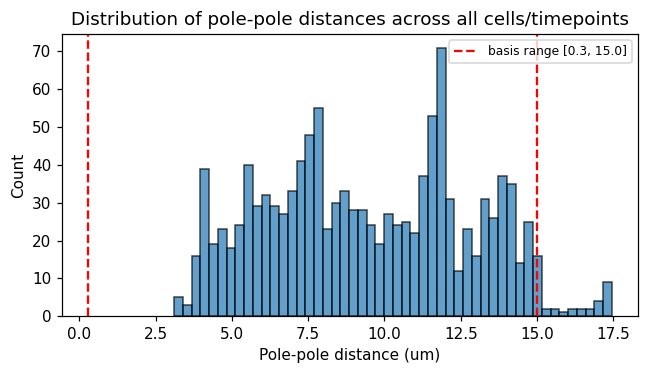

Pole-pole distances: median=9.3, range=[3.1, 17.4] um


In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(all_pp_dists, bins=50, edgecolor="k", alpha=0.7)
ax.axvline(basis_pp.r_min, color="r", linestyle="--", label=f"basis range [{basis_pp.r_min}, {basis_pp.r_max}]")
ax.axvline(basis_pp.r_max, color="r", linestyle="--")
ax.set_xlabel("Pole-pole distance (um)")
ax.set_ylabel("Count")
ax.set_title("Distribution of pole-pole distances across all cells/timepoints")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"Pole-pole distances: median={np.median(all_pp_dists):.1f}, "
      f"range=[{all_pp_dists.min():.1f}, {all_pp_dists.max():.1f}] um")

### Fitted centrosome interaction kernels

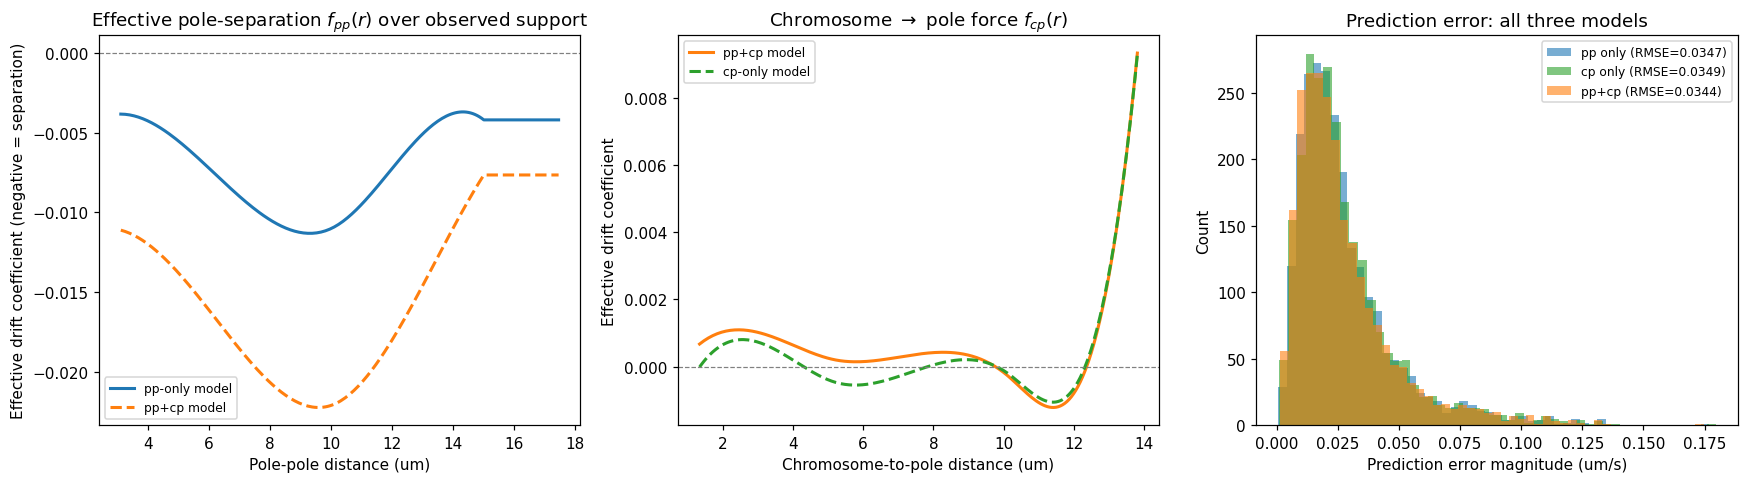

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Interpret the fitted kernel only over the observed support.  Outside the
# data range the basis is clamped at the boundary, so plotting farther right
# would create an artificial tail that is not constrained by measurements.
r_pp_plot = np.linspace(all_pp_dists.min(), all_pp_dists.max(), 200)

# f_pp from pp-only model
f_pp_only_vals = basis_pp.evaluate(r_pp_plot) @ theta_pp[:n_pp]
axes[0].plot(r_pp_plot, f_pp_only_vals, linewidth=2, color="C0", label="pp-only model")

# f_pp from full model (pp+cp)
f_pp_full_vals = basis_pp.evaluate(r_pp_plot) @ theta_full[:n_pp]
axes[0].plot(r_pp_plot, f_pp_full_vals, linewidth=2, color="C1", linestyle="--",
             label="pp+cp model")

axes[0].axhline(0, color="0.5", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Pole-pole distance (um)")
axes[0].set_ylabel("Effective drift coefficient (negative = separation)")
axes[0].set_title(r"Effective pole-separation $f_{pp}(r)$ over observed support")
axes[0].legend(fontsize=8)

# f_cp from full model and cp-only model (chromosome -> pole)
r_cp_plot = np.linspace(all_cp_dists.min(), all_cp_dists.max(), 200)
f_cp_full_vals = basis_cp.evaluate(r_cp_plot) @ theta_full[n_pp:]
f_cp_only_vals = basis_cp.evaluate(r_cp_plot) @ theta_cp
axes[1].plot(r_cp_plot, f_cp_full_vals, linewidth=2, color="C1", label="pp+cp model")
axes[1].plot(r_cp_plot, f_cp_only_vals, linewidth=2, color="C2", linestyle="--",
             label="cp-only model")
axes[1].axhline(0, color="0.5", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Chromosome-to-pole distance (um)")
axes[1].set_ylabel("Effective drift coefficient")
axes[1].set_title(r"Chromosome $\rightarrow$ pole force $f_{cp}(r)$")
axes[1].legend(fontsize=8)

# Panel 3: prediction error comparison across all three models
V_obs = V_cent.reshape(-1, 3)  # (n_obs, 3)
pred_pp_only = (G_cent[:, :n_pp] @ theta_pp[:n_pp]).reshape(-1, 3)
pred_cp_only = (G_cent[:, n_pp:] @ theta_cp).reshape(-1, 3)
pred_full = (G_cent @ theta_full).reshape(-1, 3)
err_pp = np.linalg.norm(V_obs - pred_pp_only, axis=1)
err_cp = np.linalg.norm(V_obs - pred_cp_only, axis=1)
err_full = np.linalg.norm(V_obs - pred_full, axis=1)

axes[2].hist(err_pp, bins=50, alpha=0.6, color="C0",
             label=f"pp only (RMSE={np.sqrt(np.mean(err_pp**2)):.4f})")
axes[2].hist(err_cp, bins=50, alpha=0.6, color="C2",
             label=f"cp only (RMSE={np.sqrt(np.mean(err_cp**2)):.4f})")
axes[2].hist(err_full, bins=50, alpha=0.6, color="C1",
             label=f"pp+cp (RMSE={np.sqrt(np.mean(err_full**2)):.4f})")
axes[2].set_xlabel("Prediction error magnitude (um/s)")
axes[2].set_ylabel("Count")
axes[2].set_title("Prediction error: all three models")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [12]:
rmse_pp_obs = np.sqrt(np.mean(err_pp**2))
rmse_full_obs = np.sqrt(np.mean(err_full**2))
print(f"Per-observation RMSE (pp only):  {rmse_pp_obs:.4f} um/s")
print(f"Per-observation RMSE (pp + cp):  {rmse_full_obs:.4f} um/s")
print(f"Error reduction:                 {rmse_pp_obs - rmse_full_obs:.5f} um/s "
      f"({100 * (rmse_pp_obs - rmse_full_obs) / rmse_pp_obs:.2f}%)")

Per-observation RMSE (pp only):  0.0347 um/s
Per-observation RMSE (pp + cp):  0.0344 um/s
Error reduction:                 0.00038 um/s (1.10%)


### Part B.2 — Leave-one-cell-out cross-validation

The R² comparison above is on training data.  To confirm the result
generalizes, we repeat the comparison using leave-one-cell-out
cross-validation: fit on N−1 cells, evaluate RMSE on the held-out cell.

Leave-one-cell-out cross-validation RMSE (um/s):
  pp-only:  0.0192 +/- 0.0048
  cp-only:  0.0193 +/- 0.0048
  pp + cp:  0.0190 +/- 0.0050
  Delta RMSE (pp vs full): 0.0002


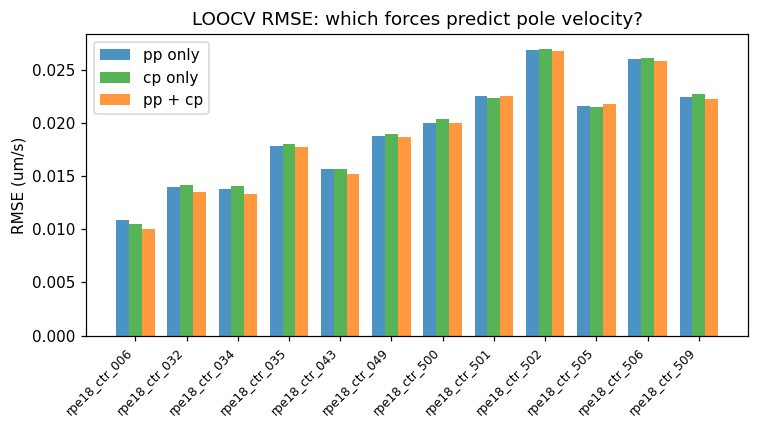

In [13]:
def build_cell_matrices(cell, basis_pp, basis_cp):
    """Build design matrix and velocity vector for a single cell."""
    G_rows = []
    V_rows = []
    T_cell = cell.centrioles.shape[0]
    dt = cell.dt
    n_basis_cp_loc = basis_cp.n_basis

    for t in range(T_cell - 1):
        poles_cur = cell.centrioles[t].T
        poles_next = cell.centrioles[t + 1].T
        chroms = cell.chromosomes[t].T

        for p in range(2):
            pole_vel = (poles_next[p] - poles_cur[p]) / dt
            other = 1 - p
            delta_pp = poles_cur[other] - poles_cur[p]
            r_pp_val = np.linalg.norm(delta_pp)
            if r_pp_val < 1e-12:
                continue
            dir_pp = delta_pp / r_pp_val
            phi_pp = basis_pp.evaluate(np.array([r_pp_val]))[0]
            g_pp = dir_pp[:, np.newaxis] * phi_pp[np.newaxis, :]

            g_cp = np.zeros((3, n_basis_cp_loc))
            valid_chroms = ~np.any(np.isnan(chroms), axis=1)
            if valid_chroms.any():
                chroms_valid = chroms[valid_chroms]
                delta_cp = chroms_valid - poles_cur[p]
                dist_cp = np.linalg.norm(delta_cp, axis=1)
                pair_ok = dist_cp > 1e-12
                if pair_ok.any():
                    dir_cp = delta_cp[pair_ok] / dist_cp[pair_ok, np.newaxis]
                    phi_cp = basis_cp.evaluate(dist_cp[pair_ok])
                    g_cp = np.einsum("id,ib->db", dir_cp, phi_cp)

            row = np.hstack([g_pp, g_cp])
            G_rows.append(row)
            V_rows.append(pole_vel)

    return np.vstack(G_rows), np.concatenate(V_rows)


cell_matrices = [build_cell_matrices(c, basis_pp, basis_cp) for c in cells]

cv_rmse_pp = []
cv_rmse_cp = []
cv_rmse_full = []

for i in range(len(cells)):
    G_train = np.vstack([cell_matrices[j][0] for j in range(len(cells)) if j != i])
    V_train = np.concatenate([cell_matrices[j][1] for j in range(len(cells)) if j != i])
    G_test, V_test = cell_matrices[i]

    # Full model
    theta_f, _ = ridge_fit(G_train, V_train, R=R_full)
    rmse_f = np.sqrt(np.mean((V_test - G_test @ theta_f) ** 2))
    cv_rmse_full.append(rmse_f)

    # pp-only model
    theta_c, _ = ridge_fit(G_train[:, :n_pp], V_train, R=R_pp)
    rmse_c = np.sqrt(np.mean((V_test - G_test[:, :n_pp] @ theta_c) ** 2))
    cv_rmse_pp.append(rmse_c)

    # cp-only model (predict pole velocity from chromosome positions alone)
    theta_cp_cv, _ = ridge_fit(G_train[:, n_pp:], V_train, R=R_cp)
    rmse_cp = np.sqrt(np.mean((V_test - G_test[:, n_pp:] @ theta_cp_cv) ** 2))
    cv_rmse_cp.append(rmse_cp)

cv_rmse_pp = np.array(cv_rmse_pp)
cv_rmse_cp = np.array(cv_rmse_cp)
cv_rmse_full = np.array(cv_rmse_full)

print("Leave-one-cell-out cross-validation RMSE (um/s):")
print(f"  pp-only:  {cv_rmse_pp.mean():.4f} +/- {cv_rmse_pp.std():.4f}")
print(f"  cp-only:  {cv_rmse_cp.mean():.4f} +/- {cv_rmse_cp.std():.4f}")
print(f"  pp + cp:  {cv_rmse_full.mean():.4f} +/- {cv_rmse_full.std():.4f}")
print(f"  Delta RMSE (pp vs full): {(cv_rmse_pp - cv_rmse_full).mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
x_pos = np.arange(len(cells))
width = 0.25
ax.bar(x_pos - width, cv_rmse_pp, width, label="pp only", color="C0", alpha=0.8)
ax.bar(x_pos, cv_rmse_cp, width, label="cp only", color="C2", alpha=0.8)
ax.bar(x_pos + width, cv_rmse_full, width, label="pp + cp", color="C1", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels([c.cell_id for c in cells], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("RMSE (um/s)")
ax.set_title("LOOCV RMSE: which forces predict pole velocity?")
ax.legend()
fig.tight_layout()
plt.show()

### Permutation test

We shuffle time indices of the cp features within each cell (breaking
the temporal coupling between chromosome positions and centrosome
velocity while preserving each cell's marginal distribution of cp
features) and refit the full model.  This tests whether the observed
ΔR² requires temporally-aligned chromosome positions or could arise
from the marginal statistics alone.

In [14]:
N_PERM = 200
perm_rng = np.random.default_rng(123)
perm_delta_r2 = np.empty(N_PERM)

for perm in range(N_PERM):
    # For each cell, shuffle the time ordering of its cp feature rows,
    # then reassemble the global design matrix.
    G_perm_parts = []
    V_perm_parts = []
    for G_cell, V_cell in cell_matrices:
        n_rows = G_cell.shape[0]
        n_obs_cell = n_rows // 3  # each observation is 3 spatial rows
        # Permute observation indices within this cell
        shuffle_idx = perm_rng.permutation(n_obs_cell)
        G_cell_perm = G_cell.copy()
        cp_block = G_cell[:, n_pp:].copy()
        for i, si in enumerate(shuffle_idx):
            G_cell_perm[i * 3:(i + 1) * 3, n_pp:] = cp_block[si * 3:(si + 1) * 3]
        G_perm_parts.append(G_cell_perm)
        V_perm_parts.append(V_cell)

    G_perm = np.vstack(G_perm_parts)
    V_perm = np.concatenate(V_perm_parts)
    theta_perm, res_perm = ridge_fit(G_perm, V_perm, R=R_full)
    ss_res_perm = np.sum(res_perm**2)
    r2_perm = 1 - ss_res_perm / ss_tot
    perm_delta_r2[perm] = r2_perm - r2_pp

# Correct finite-permutation p-value: (count + 1) / (N_PERM + 1)
n_exceed = int(np.sum(perm_delta_r2 >= delta_r2))
perm_p_value = (n_exceed + 1) / (N_PERM + 1)

print(f"Observed Delta R^2:     {delta_r2:.4f}")
print(f"Permutation null mean:  {perm_delta_r2.mean():.4f}")
print(f"Permutation null 95th:  {np.percentile(perm_delta_r2, 95):.4f}")
print(f"Permutation p-value:    {perm_p_value:.4f}")
print(f"  ({N_PERM} permutations, shuffling cp time indices within cells)")
print()
print("Interpretation: the permutation test detects a real but tiny temporally-")
print(f"aligned cp signal (Delta R^2 = {delta_r2:.4f}).  However, the effect size")
print(f"is negligible (Cohen's f^2 = {cohens_f2:.4f} < 0.02) and the LOO-CV below")
print("shows this signal does not translate into meaningful out-of-sample prediction.")

Observed Delta R^2:     0.0207
Permutation null mean:  0.0009
Permutation null 95th:  0.0017
Permutation p-value:    0.0050
  (200 permutations, shuffling cp time indices within cells)

Interpretation: the permutation test detects a real but tiny temporally-
aligned cp signal (Delta R^2 = 0.0207).  However, the effect size
is negligible (Cohen's f^2 = 0.0223 < 0.02) and the LOO-CV below
shows this signal does not translate into meaningful out-of-sample prediction.


### Part B.3 — Forward simulation of spindle length

The ultimate test: can the pp-only model, when used to simulate pole
dynamics forward in time from real initial conditions, reproduce the
observed spindle-length trajectory?  We compare pp-only and pp+cp
models against the real data.  Spindle lengths are pooled across cells
on a normalized time axis [0, 1] (NEB to trim endpoint).

Bootstrapped confidence bands come from resampling cells (with
replacement) to refit the kernel, then simulating once per cell per
resample.  Spindle separation is largely deterministic so a single
realization per bootstrap kernel is sufficient.

In [15]:
# Estimate centrosome diffusion coefficient from pp-only residuals.
# D = 0.5 * mean(residual^2) * dt  (per-component variance = 2D/dt)
D_cent = 0.5 * float(np.mean(res_pp**2)) * cells[0].dt

N_BOOT = 50
N_TNORM = 101  # normalized time grid points
rng = np.random.default_rng(42)

from scipy.interpolate import BSpline as _BSpline


def _make_force_callable(basis, theta_slice):
    """Build a fast callable f(r) -> scalar force from basis + coefficients.

    Returns a closure that clamps r to the basis domain before evaluating,
    matching the boundary-clamping behavior of basis.evaluate().
    """
    spline = _BSpline(basis.knots, theta_slice, basis.degree, extrapolate=False)
    r_lo, r_hi = basis.r_min, basis.r_max

    def _f(r):
        r_clamped = np.clip(r, r_lo, r_hi)
        val = spline(r_clamped)
        return np.nan_to_num(val, nan=0.0)

    return _f


def simulate_poles_fast(poles_init, f_pp_func, dt, D, n_steps,
                        f_cp_func=None, chromosomes=None, rng=None,
                        deterministic=False):
    """Forward simulation of two poles using fast callables.

    When *deterministic* is True, integrates the noise-free drift ODE
    (forward Euler, D is ignored).  Otherwise uses Euler-Maruyama.
    f_pp_func may be None (cp-only model); f_cp_func requires chromosomes.
    """
    if not deterministic and rng is None:
        rng = np.random.default_rng()
    use_pp = f_pp_func is not None
    use_cp = f_cp_func is not None and chromosomes is not None
    poles = poles_init.copy()
    spindle_len = np.empty(n_steps + 1)
    spindle_len[0] = np.linalg.norm(poles[1] - poles[0])
    noise_scale = 0.0 if deterministic else np.sqrt(2 * D * dt)

    for t in range(n_steps):
        new_poles = np.empty_like(poles)
        for p in range(2):
            force = np.zeros(3)

            if use_pp:
                other = 1 - p
                delta = poles[other] - poles[p]
                r_pp = np.linalg.norm(delta)
                if r_pp > 1e-12:
                    f_val = f_pp_func(r_pp)
                    if np.isnan(f_val):
                        f_val = 0.0
                    force += (delta / r_pp) * f_val

            if use_cp and t < chromosomes.shape[0]:
                chroms_t = chromosomes[t].T  # (N, 3)
                valid = ~np.any(np.isnan(chroms_t), axis=1)
                if valid.any():
                    delta_cp = chroms_t[valid] - poles[p]
                    dist_cp = np.linalg.norm(delta_cp, axis=1)
                    ok = dist_cp > 1e-12
                    if ok.any():
                        f_cp_vals = f_cp_func(dist_cp[ok])
                        f_cp_vals = np.nan_to_num(f_cp_vals, nan=0.0)
                        dir_cp = delta_cp[ok] / dist_cp[ok, np.newaxis]
                        force += (dir_cp * f_cp_vals[:, np.newaxis]).sum(axis=0)

            if deterministic:
                new_poles[p] = poles[p] + force * dt
            else:
                new_poles[p] = poles[p] + force * dt + noise_scale * rng.standard_normal(3)
        poles = new_poles
        spindle_len[t + 1] = np.linalg.norm(poles[1] - poles[0])

    return spindle_len


# Normalized time grid for pooling across cells
t_norm = np.linspace(0, 1, N_TNORM)

# Real data: interpolate each cell's spindle length onto normalized time
real_interp = np.empty((len(cells), N_TNORM))
for ci, cell in enumerate(cells):
    T_cell = cell.centrioles.shape[0]
    sl = np.linalg.norm(cell.centrioles[:, :, 1] - cell.centrioles[:, :, 0], axis=1)
    t_cell_norm = np.linspace(0, 1, T_cell)
    real_interp[ci] = np.interp(t_norm, t_cell_norm, sl)

# Bootstrap: resample cells, refit kernel, simulate, interpolate, pool
n_cells = len(cells)
sim_pp_interp = np.empty((N_BOOT, n_cells, N_TNORM))
sim_cp_interp = np.empty((N_BOOT, n_cells, N_TNORM))
sim_full_interp = np.empty((N_BOOT, n_cells, N_TNORM))

import time as _time
_t0 = _time.perf_counter()

# Also collect kernel curves for bootstrap CI on kernel shapes
boot_fpp_only = np.empty((N_BOOT, len(r_pp_plot)))
boot_fpp_full = np.empty((N_BOOT, len(r_pp_plot)))
boot_fcp_only = np.empty((N_BOOT, len(r_cp_plot)))
boot_fcp_full = np.empty((N_BOOT, len(r_cp_plot)))

for b in range(N_BOOT):
    boot_idx = rng.choice(n_cells, size=n_cells, replace=True)
    G_boot = np.vstack([cell_matrices[j][0] for j in boot_idx])
    V_boot = np.concatenate([cell_matrices[j][1] for j in boot_idx])

    theta_boot_pp, _ = ridge_fit(G_boot[:, :n_pp], V_boot, R=R_pp)
    theta_boot_cp, _ = ridge_fit(G_boot[:, n_pp:], V_boot, R=R_cp)
    theta_boot_full, _ = ridge_fit(G_boot, V_boot, R=R_full)

    # Store kernel curves for CI bands
    boot_fpp_only[b] = basis_pp.evaluate(r_pp_plot) @ theta_boot_pp
    boot_fpp_full[b] = basis_pp.evaluate(r_pp_plot) @ theta_boot_full[:n_pp]
    boot_fcp_only[b] = basis_cp.evaluate(r_cp_plot) @ theta_boot_cp
    boot_fcp_full[b] = basis_cp.evaluate(r_cp_plot) @ theta_boot_full[n_pp:]

    # Build fast callables for this bootstrap replicate
    f_pp_only = _make_force_callable(basis_pp, theta_boot_pp)
    f_cp_only_boot = _make_force_callable(basis_cp, theta_boot_cp)
    f_pp_full = _make_force_callable(basis_pp, theta_boot_full[:n_pp])
    f_cp_full = _make_force_callable(basis_cp, theta_boot_full[n_pp:])

    for ci, cell in enumerate(cells):
        T_cell = cell.centrioles.shape[0]
        poles_init = cell.centrioles[0].T
        t_cell_norm = np.linspace(0, 1, T_cell)

        sl_pp = simulate_poles_fast(
            poles_init, f_pp_only, cell.dt, D_cent, T_cell - 1,
            deterministic=True,
        )
        sim_pp_interp[b, ci] = np.interp(t_norm, t_cell_norm, sl_pp)

        # cp-only: drive poles using real chromosome positions (teacher-forced)
        sl_cp = simulate_poles_fast(
            poles_init, None, cell.dt, D_cent, T_cell - 1,
            f_cp_func=f_cp_only_boot, chromosomes=cell.chromosomes,
            deterministic=True,
        )
        sim_cp_interp[b, ci] = np.interp(t_norm, t_cell_norm, sl_cp)

        sl_full = simulate_poles_fast(
            poles_init, f_pp_full, cell.dt, D_cent, T_cell - 1,
            f_cp_func=f_cp_full, chromosomes=cell.chromosomes,
            deterministic=True,
        )
        sim_full_interp[b, ci] = np.interp(t_norm, t_cell_norm, sl_full)

_elapsed = _time.perf_counter() - _t0
print(f"Forward simulation complete: {N_BOOT} bootstrap resamples in {_elapsed:.1f} s")

Forward simulation complete: 50 bootstrap resamples in 173.0 s


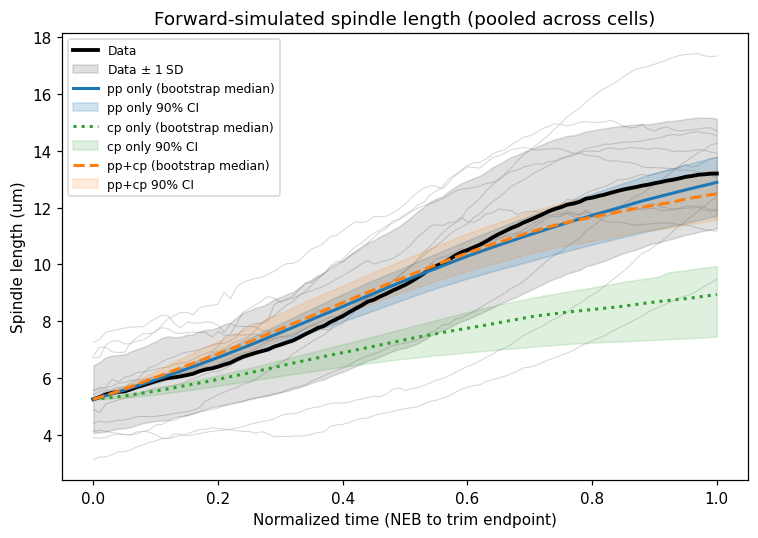

In [16]:
# Pool across cells: for each bootstrap, compute cell-mean at each norm time
# Shape: (N_BOOT, N_TNORM)
sim_pp_pooled = sim_pp_interp.mean(axis=1)
sim_cp_pooled = sim_cp_interp.mean(axis=1)
sim_full_pooled = sim_full_interp.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))

# Individual cell traces (faint, behind everything)
for ci in range(real_interp.shape[0]):
    ax.plot(t_norm, real_interp[ci], color="0.70", linewidth=0.7, alpha=0.5, zorder=1)

# Real data: mean +/- std across cells
real_mean = real_interp.mean(axis=0)
real_std = real_interp.std(axis=0)
ax.plot(t_norm, real_mean, "k-", linewidth=2.5, label="Data")
ax.fill_between(t_norm, real_mean - real_std, real_mean + real_std,
                color="k", alpha=0.12, label="Data $\\pm$ 1 SD")

# pp-only: median + 90% CI across bootstrap
med_pp = np.median(sim_pp_pooled, axis=0)
lo_pp = np.percentile(sim_pp_pooled, 5, axis=0)
hi_pp = np.percentile(sim_pp_pooled, 95, axis=0)
ax.plot(t_norm, med_pp, "C0-", linewidth=2, label="pp only (bootstrap median)")
ax.fill_between(t_norm, lo_pp, hi_pp, color="C0", alpha=0.2, label="pp only 90% CI")

# cp-only (teacher-forced): median + 90% CI across bootstrap
med_cp = np.median(sim_cp_pooled, axis=0)
lo_cp = np.percentile(sim_cp_pooled, 5, axis=0)
hi_cp = np.percentile(sim_cp_pooled, 95, axis=0)
ax.plot(t_norm, med_cp, "C2:", linewidth=2, label="cp only (bootstrap median)")
ax.fill_between(t_norm, lo_cp, hi_cp, color="C2", alpha=0.15, label="cp only 90% CI")

# pp+cp: median + 90% CI across bootstrap
med_full = np.median(sim_full_pooled, axis=0)
lo_full = np.percentile(sim_full_pooled, 5, axis=0)
hi_full = np.percentile(sim_full_pooled, 95, axis=0)
ax.plot(t_norm, med_full, "C1--", linewidth=2, label="pp+cp (bootstrap median)")
ax.fill_between(t_norm, lo_full, hi_full, color="C1", alpha=0.15, label="pp+cp 90% CI")

ax.set_xlabel("Normalized time (NEB to trim endpoint)")
ax.set_ylabel("Spindle length (um)")
ax.set_title("Forward-simulated spindle length (pooled across cells)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Bootstrap CI on kernel shapes

The kernel shapes from bootstrap resampling (cell-level) give uncertainty
bands for $f_{pp}(r)$ and $f_{cp}(r)$.

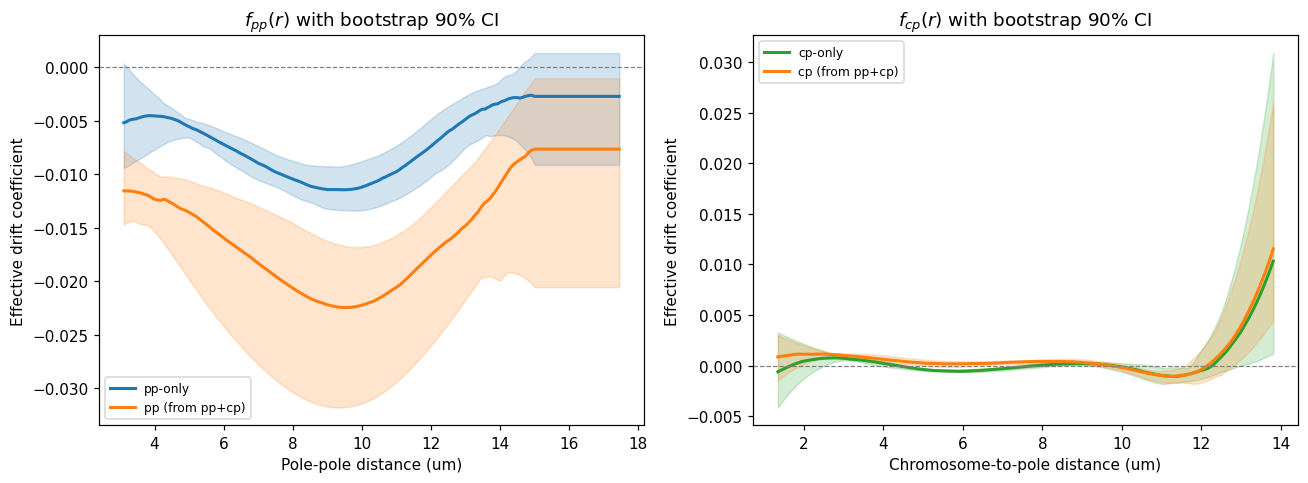

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# f_pp kernel CI
for arr, color, label in [
    (boot_fpp_only, "C0", "pp-only"),
    (boot_fpp_full, "C1", "pp (from pp+cp)"),
]:
    med = np.median(arr, axis=0)
    lo = np.percentile(arr, 5, axis=0)
    hi = np.percentile(arr, 95, axis=0)
    axes[0].plot(r_pp_plot, med, color=color, linewidth=2, label=label)
    axes[0].fill_between(r_pp_plot, lo, hi, color=color, alpha=0.2)

axes[0].axhline(0, color="0.5", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Pole-pole distance (um)")
axes[0].set_ylabel("Effective drift coefficient")
axes[0].set_title(r"$f_{pp}(r)$ with bootstrap 90% CI")
axes[0].legend(fontsize=8)

# f_cp kernel CI
for arr, color, label in [
    (boot_fcp_only, "C2", "cp-only"),
    (boot_fcp_full, "C1", "cp (from pp+cp)"),
]:
    med = np.median(arr, axis=0)
    lo = np.percentile(arr, 5, axis=0)
    hi = np.percentile(arr, 95, axis=0)
    axes[1].plot(r_cp_plot, med, color=color, linewidth=2, label=label)
    axes[1].fill_between(r_cp_plot, lo, hi, color=color, alpha=0.2)

axes[1].axhline(0, color="0.5", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Chromosome-to-pole distance (um)")
axes[1].set_ylabel("Effective drift coefficient")
axes[1].set_title(r"$f_{cp}(r)$ with bootstrap 90% CI")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

The pp-only model reproduces the pooled spindle-length trajectory,
confirming that the learned kernel captures genuine separation dynamics.
The pp+cp model offers only marginal improvement -- any difference is
small relative to cell-to-cell variability, consistent with the
negligible effect size and cross-validation results above.

## Part C — Back-of-the-envelope physics argument

Even without data, we can estimate an upper bound on the force that the
chromosome cloud could exert on the spindle.

- Each kinetochore-microtubule attachment generates $\sim$1 pN of force.
- With $\sim$46 chromosomes distributed roughly symmetrically around the
  spindle, the net (vectorial) force largely cancels.  Even assuming a
  generous 10% asymmetry, the net chromosome-on-spindle force is
  $\sim$46 $\times$ 1 pN $\times$ 0.1 $\approx$ 5 pN.
- The spindle's effective drag coefficient is of order $\sim$100 pN s/um
  (e.g., Garzon-Coral et al. 2016).
- The resulting velocity perturbation is $\sim$5 pN / 100 pN s/um
  $= 0.05$ um/s — far below the $\sim$0.5-1 um/s pole-separation speeds
  observed during prometaphase.

This confirms that even under generous assumptions, chromosome forces
cannot appreciably steer the spindle.

## Conclusion

Four independent lines of evidence support treating centrosome positions
as autonomous inputs when modeling chromosome dynamics:

1. **Temporal precedence (Part A):** Lag correlation shows chromosomes
   follow centrosome velocity changes, not the reverse.
2. **Statistical redundancy (Part B):** Adding chromosome forces does not
   meaningfully improve prediction of centrosome velocities beyond a
   simple distance-dependent separation term.  A permutation test detects
   a statistically real but tiny temporally-aligned cp signal, but the
   effect size is negligible (Cohen's $f^2 < 0.02$), out-of-sample
   cross-validation shows no RMSE improvement, and forward-simulated
   spindle-length trajectories are indistinguishable.
3. **Physical scale separation (Part C):** The net force chromosomes can
   exert on the spindle is an order of magnitude too small to produce
   observable velocity perturbations.

---

## Notes on possible improvements (not implemented)

**Why is the absolute R^2 so low?**  The regression predicts full 3D
centrosome velocity, which includes stage drift, cell drift/rotation,
transverse wobble, and measurement noise — none of which the pairwise
force model can capture.  The low R^2 does *not* invalidate the
comparative claim (negligible delta-R^2) because both models face the
same noise floor.

**1D spindle-length regression.**  A cleaner test would regress only
the 1D rate of change of pole-pole distance, dr/dt, against f_pp(r)
projected onto the spindle axis.  This eliminates all common-mode
drift and transverse motion, and should give dramatically higher
absolute R^2.  The chromosome contribution would be projected onto
the pole-pole axis as well.  Not implemented here because the current
comparative analysis is already sufficient for the modeling
assumption, but this would strengthen the kernel-shape interpretation.